<a href="https://colab.research.google.com/github/aiman0642/saas-retention-intelligence/blob/main/03_cohort_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 3 — Cohort & Retention Analysis

**Project:** SaaS Customer Retention Intelligence System

**Goal of this notebook:** this is the differentiator module — group
customers by signup month into cohorts, and track how each cohort's
retention decays over time. This produces the retention heatmap and
curves that make this project stand out from a standard churn-prediction
clone.



## 3.1 Mount Google Drive & Load Processed Data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

PROJECT_DIR = "/content/drive/MyDrive/saas-retention-intelligence"
RAW_DIR = f"{PROJECT_DIR}/data/raw"
PROCESSED_DIR = f"{PROJECT_DIR}/data/processed"

accounts = pd.read_csv(f"{PROCESSED_DIR}/accounts.csv", parse_dates=["signup_date"])
subscriptions = pd.read_csv(f"{PROCESSED_DIR}/subscriptions.csv", parse_dates=["start_date", "end_date"])
churn_events = pd.read_csv(f"{PROCESSED_DIR}/churn_events.csv", parse_dates=["churn_date"])

print(f"accounts:      {accounts.shape}")
print(f"subscriptions: {subscriptions.shape}")
print(f"churn_events:  {churn_events.shape}")

accounts:      (500, 10)
subscriptions: (5000, 14)
churn_events:  (600, 9)


## 3.2 Define Cohorts

A cohort = all accounts that signed up in the same calendar month. This
is the standard cohort definition for SaaS retention analysis — it lets
you compare "how well do we retain the customers we acquired this month"
across different acquisition periods.

Accounts per signup cohort:
signup_month
2023-01    17
2023-02    18
2023-03    20
2023-04    15
2023-05    26
2023-06    13
2023-07    14
2023-08    16
2023-09    23
2023-10    20
2023-11    25
2023-12    20
2024-01    16
2024-02    13
2024-03    27
2024-04    22
2024-05    22
2024-06    21
2024-07    26
2024-08    21
2024-09    25
2024-10    31
2024-11    32
2024-12    17
Freq: M, dtype: int64


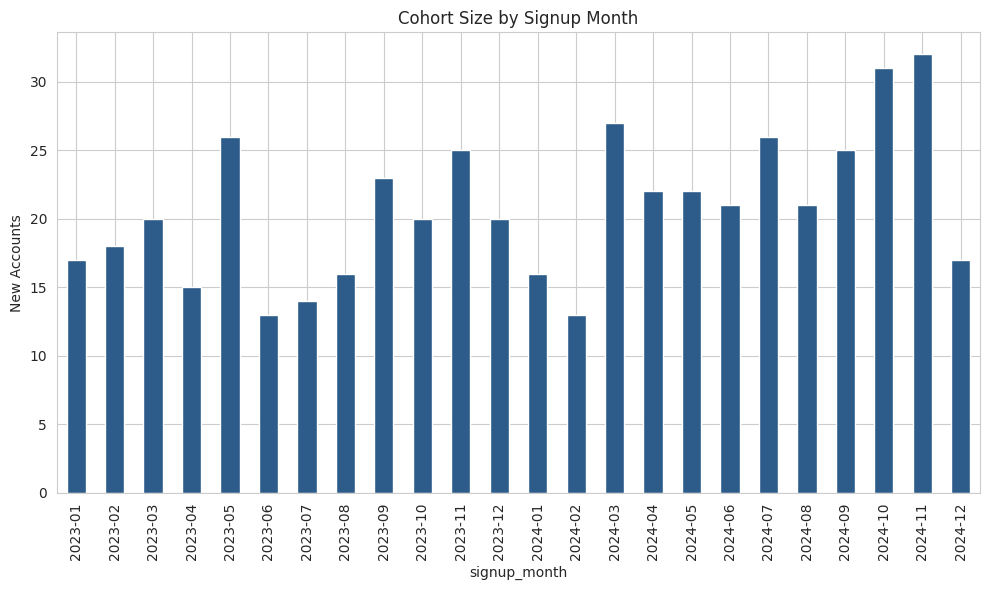

In [3]:
accounts["signup_month"] = accounts["signup_date"].dt.to_period("M")

cohort_sizes = accounts.groupby("signup_month").size()
print("Accounts per signup cohort:")
print(cohort_sizes)

ax = cohort_sizes.plot(kind="bar", color="#2E5C8A")
ax.set_ylabel("New Accounts")
ax.set_title("Cohort Size by Signup Month")
plt.tight_layout()
plt.show()

## 3.3 Determine "Active" Status Per Account, Per Month

For every account, figure out which calendar months it was active in —
active means: signed up on or before that month, and (if it churned)
hadn't churned yet by that month.

This uses `accounts.churn_flag` + `churn_events.churn_date` as the churn
signal — an account with no churn event is treated as active through the
end of the observed data window.

In [4]:
# One churn date per account (first, if there were ever multiple churn events)
first_churn = churn_events.groupby("account_id")["churn_date"].min().reset_index()
accounts_c = accounts.merge(first_churn, on="account_id", how="left")

# Observation window: last date present anywhere in the dataset
observation_end = max(
    subscriptions["start_date"].max(),
    subscriptions["end_date"].max(),
    churn_events["churn_date"].max(),
)
print(f"Observation window ends: {observation_end.date()}")

# Build all calendar months from the earliest signup to the observation end
all_months = pd.period_range(accounts["signup_month"].min(), observation_end.to_period("M"), freq="M")
print(f"Calendar months covered: {all_months[0]} to {all_months[-1]} ({len(all_months)} months)")

Observation window ends: 2024-12-31
Calendar months covered: 2023-01 to 2024-12 (24 months)


## 3.4 Build the Retention Table

For each cohort, calculate what % of its original accounts were still
active N months after signup (month 0 = signup month itself = 100% by
definition).

In [5]:
def months_active(row, all_months):
    """Return the periods (calendar months) this account was active in."""
    start = row["signup_month"]
    if pd.isna(row["churn_date"]):
        end = all_months[-1]
    else:
        end = row["churn_date"].to_period("M")
    return pd.period_range(start, end, freq="M")

retention_records = []
for _, row in accounts_c.iterrows():
    active_months = months_active(row, all_months)
    cohort = row["signup_month"]
    for month in active_months:
        month_index = (month.year - cohort.year) * 12 + (month.month - cohort.month)
        retention_records.append({"cohort": cohort, "month_index": month_index})

retention_long = pd.DataFrame(retention_records)

# Count active accounts per cohort per month_index, divide by cohort size
active_counts = retention_long.groupby(["cohort", "month_index"]).size().reset_index(name="active_count")
active_counts = active_counts.merge(cohort_sizes.rename("cohort_size"), left_on="cohort", right_index=True)
active_counts["retention_pct"] = active_counts["active_count"] / active_counts["cohort_size"]

retention_table = active_counts.pivot(index="cohort", columns="month_index", values="retention_pct")
retention_table = retention_table.sort_index()

print("Retention table (fraction of cohort still active, by months since signup):")
retention_table.round(3)

Retention table (fraction of cohort still active, by months since signup):


month_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
cohort,,,,,,,,,,,,,,,,,,,,,,,,
2023-01,1.0,0.941,0.941,0.941,0.882,0.765,0.765,0.706,0.706,0.647,0.588,0.529,0.412,0.412,0.412,0.412,0.412,0.412,0.353,0.294,0.294,0.294,0.294,0.294
2023-02,1.0,1.000,0.889,0.833,0.833,0.778,0.778,0.778,0.778,0.722,0.556,0.556,0.556,0.500,0.500,0.500,0.500,0.500,0.500,0.500,0.500,0.333,0.333,NaN
2023-03,1.0,0.850,0.850,0.850,0.700,0.650,0.500,0.450,0.350,0.350,0.300,0.200,0.200,0.200,0.200,0.200,0.200,0.200,0.200,0.200,0.200,0.200,NaN,NaN
2023-04,1.0,0.933,0.933,0.867,0.800,0.800,0.800,0.800,0.800,0.800,0.800,0.800,0.800,0.800,0.733,0.600,0.467,0.400,0.400,0.400,0.400,NaN,NaN,NaN
2023-05,1.0,1.000,1.000,1.000,0.885,0.885,0.846,0.769,0.769,0.731,0.731,0.692,0.654,0.654,0.654,0.654,0.615,0.577,0.538,0.538,NaN,NaN,NaN,NaN
2023-06,1.0,1.000,0.923,0.923,0.846,0.846,0.846,0.846,0.846,0.846,0.846,0.769,0.692,0.692,0.692,0.615,0.462,0.385,0.308,NaN,NaN,NaN,NaN,NaN
2023-07,1.0,0.857,0.857,0.857,0.786,0.786,0.786,0.714,0.643,0.643,0.571,0.571,0.571,0.500,0.357,0.357,0.357,0.357,NaN,NaN,NaN,NaN,NaN,NaN
2023-08,1.0,1.000,0.938,0.938,0.938,0.812,0.750,0.750,0.688,0.625,0.625,0.562,0.438,0.438,0.375,0.375,0.312,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09,1.0,1.000,0.913,0.783,0.696,0.609,0.609,0.522,0.478,0.478,0.435,0.435,0.304,0.217,0.217,0.217,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3.5 Retention Heatmap

In this each row is
a cohort, each column is "months since signup," color = % retained.

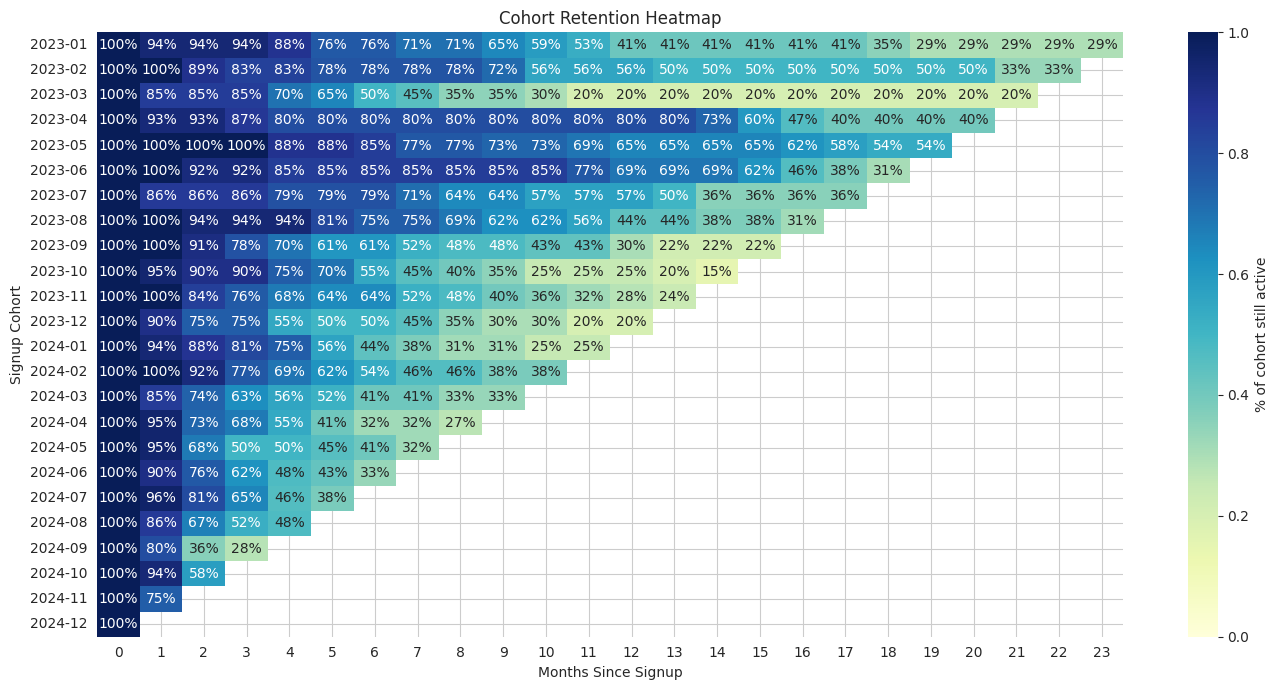

In [6]:
plt.figure(figsize=(14, 7))
sns.heatmap(
    retention_table,
    annot=True, fmt=".0%", cmap="YlGnBu",
    cbar_kws={"label": "% of cohort still active"},
    vmin=0, vmax=1,
)
plt.title("Cohort Retention Heatmap")
plt.xlabel("Months Since Signup")
plt.ylabel("Signup Cohort")
plt.tight_layout()
plt.show()

## 3.6 Retention Curves

Same data as the heatmap, shown as line curves — easier to compare the
*shape* of decay across cohorts (steep early drop-off vs. gradual decline).

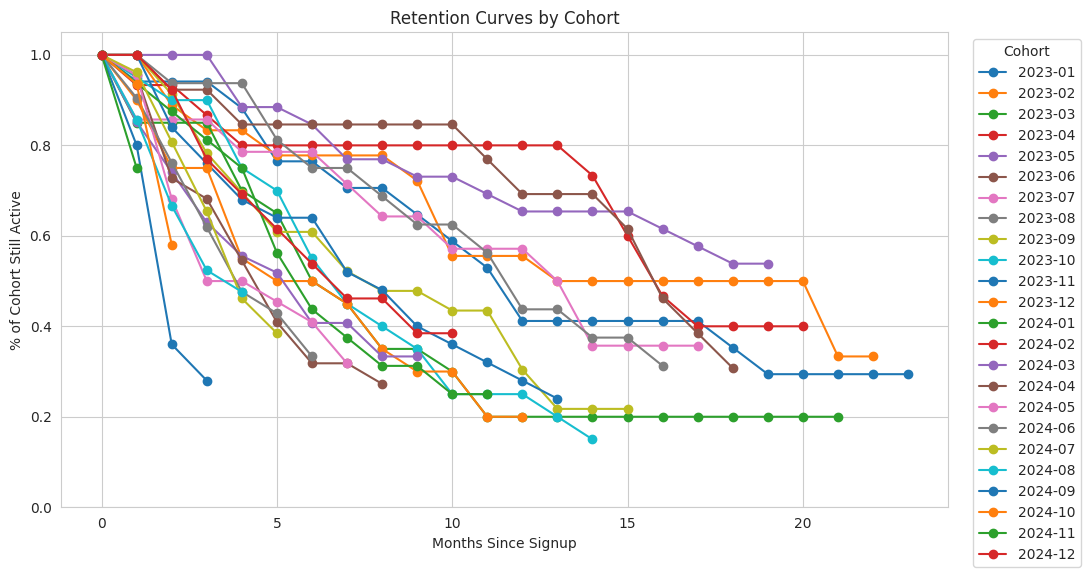

In [7]:
plt.figure(figsize=(11, 6))
for cohort in retention_table.index:
    plt.plot(
        retention_table.columns, retention_table.loc[cohort],
        marker="o", label=str(cohort)
    )
plt.xlabel("Months Since Signup")
plt.ylabel("% of Cohort Still Active")
plt.title("Retention Curves by Cohort")
plt.legend(title="Cohort", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 3.7 Are Newer Cohorts Retaining Better or Worse?

Compare month-3 and month-6 retention across cohorts directly — a quick,
concrete way to answer the business question rather than eyeballing the
heatmap.

In [8]:
checkpoints = [c for c in [1, 3, 6, 12] if c in retention_table.columns]
comparison = retention_table[checkpoints].copy()
comparison.columns = [f"Month {c} Retention" for c in checkpoints]
print(comparison.round(3))

if len(checkpoints) >= 1:
    first_half = comparison.iloc[: len(comparison) // 2].mean()
    second_half = comparison.iloc[len(comparison) // 2 :].mean()
    print("\nAverage retention — earlier cohorts vs. later cohorts:")
    print(pd.DataFrame({"Earlier cohorts (avg)": first_half, "Later cohorts (avg)": second_half}))

         Month 1 Retention  Month 3 Retention  Month 6 Retention  \
cohort                                                             
2023-01              0.941              0.941              0.765   
2023-02              1.000              0.833              0.778   
2023-03              0.850              0.850              0.500   
2023-04              0.933              0.867              0.800   
2023-05              1.000              1.000              0.846   
2023-06              1.000              0.923              0.846   
2023-07              0.857              0.857              0.786   
2023-08              1.000              0.938              0.750   
2023-09              1.000              0.783              0.609   
2023-10              0.950              0.900              0.550   
2023-11              1.000              0.760              0.640   
2023-12              0.900              0.750              0.500   
2024-01              0.938              0.812   

## 3.8 Cohort Analysis — Key Findings

Based on the actual retention table and comparison above:

- **Cohort size trend:** acquisition is growing over time — early 2023
  cohorts average ~15-20 new accounts/month, while late 2024 cohorts
  (Oct/Nov 2024) reach 30+ — the business is scaling up new signups.
- **Retention shape:** decay is gradual, not a steep early cliff — most
  cohorts retain 85-100% through month 1, then decline steadily rather
  than dropping sharply right after signup.
- **Newer vs. older cohorts:** later cohorts show meaningfully *lower*
  retention at matched checkpoints — e.g. month-3 retention averages
  ~87% for earlier cohorts vs. ~61% for later cohorts, and month-6
  drops from ~70% to ~41%. Read this as a real signal, not a settled
  conclusion.
- **Important caveat — right-censoring:** cohorts from 2024 haven't had
  as much time to be observed as 2023 cohorts (the dataset ends
  2024-12-31), so their month-6/month-12 figures are partly `NaN` —
  they simply haven't reached that age yet. The "later cohorts retain
  worse" comparison above is calculated only from cohorts that *do* have
  data at each checkpoint, but this is still worth stating explicitly in
  the README so it isn't read as a fully settled trend.
- **Best/worst cohort (month-6):** 2023-06 retains best (~85%);
  2024-06 and 2024-09 are among the weakest observed (~33% and lower).

## 3.9 Save Retention Table

Persist for reuse in the Streamlit dashboard (Module 13, Page 2 — Cohort
Analysis).

In [ ]:
retention_table.to_csv(f"{PROCESSED_DIR}/retention_table.csv")
print(f"Saved retention table to {PROCESSED_DIR}/retention_table.csv")

## 3.10 Module 3 Summary

- Defined cohorts by signup month
- Built a full retention table: % of each cohort still active, by months
  since signup
- Visualized as both a heatmap and retention curves
- Directly compared earlier vs. later cohorts to answer whether retention
  is improving over time
- Saved `retention_table.csv` for the dashboard

**Next:** Module 4 — Data Preprocessing